# Select and save Loop 3 recipes

Loads the optimized solutions, checks uncertainty calibration, and selects/saves the final recipes.

In [19]:
from pathlib import Path 
import os 
import sys
sys.path.insert(0, "../../../../../../shared_utils")
from experiment_utils import manual_filtering

import matplotlib.pyplot as plt 
import matplotlib.colors as mcolors
import scanpy as sc
import numpy as np 
import pandas as pd
import scipy as sp 
import seaborn as sns
from tqdm import tqdm 
import copy
import math
import yaml
import fpsample
import pickle as pkl

## Load solutions 

In [20]:
def load_pure_cell_type_solutions(
    path_to_results,
    paths,
    cell_types,
):
    # Path to results 
    path_to_results = Path(path_to_results)

    # Final cell type dictionary
    pure_cell_type_solution_dict = {
        cell_type: [] for cell_type in cell_types
    }

    for experiment_folder in tqdm(paths):

        cell_type_file_paths = path_to_results / experiment_folder

        if not cell_type_file_paths.exists():
            continue

        # Iterate through cell types
        for cell_type in os.listdir(cell_type_file_paths):

            if cell_type not in cell_types:
                continue

            config_exp_folders = cell_type_file_paths / cell_type

            if not config_exp_folders.is_dir():
                continue

            # Iterate through experiment configs
            for config_exp_folder in os.listdir(config_exp_folders):

                exp_folder = config_exp_folders / config_exp_folder

                if not exp_folder.is_dir():
                    continue

                # Check candidates.csv exists
                if "candidates.csv" not in os.listdir(exp_folder):
                    continue

                uncertainty_path = (
                    exp_folder
                    / "uncertainty_annotation"
                    / "candidates_with_uncertainties.csv"
                )

                # Check uncertainty annotation exists
                if uncertainty_path.exists():

                    candidate_with_uncertainty_df = pd.read_csv(
                        uncertainty_path
                    )

                    candidate_with_uncertainty_df["run_name"] = [
                        Path(file).name
                        for file in candidate_with_uncertainty_df[
                            "cfg:paths:dump_dir"
                        ]
                    ]

                    pure_cell_type_solution_dict[cell_type].append(
                        candidate_with_uncertainty_df
                    )

    return pure_cell_type_solution_dict

## Read annotation file

In [21]:
ANNOTATION_CFG_FILE = "../../../../../../inverse/loss_guidance/config/annotation/bloodplus_loop3.yaml"
with open(ANNOTATION_CFG_FILE, "r") as fb:
    annotation_cfg_loop3 = yaml.safe_load(fb)
protocol_cols_loop3 = annotation_cfg_loop3["protocol_columns"]

ANNOTATION_CFG_FILE_BOUNDS = "../../../../../../inverse/loss_guidance/config/constraints/default_all_cols_loop3.yaml"
with open(ANNOTATION_CFG_FILE_BOUNDS, "r") as fb:
    annotation_cfg_bound_loop3 = yaml.safe_load(fb)
ubound_dict_loop3, lbound_dict_loop3 = annotation_cfg_bound_loop3["ubound_dict"],  annotation_cfg_bound_loop3["lbound_dict"]

# Collect per parameter bounds 
bounds_loop3 = {}
for param in lbound_dict_loop3:
    bounds_loop3[param] = (lbound_dict_loop3[param], ubound_dict_loop3[param])

In [22]:
loop3_only = ['il7_[ng_ml]', 'mcsf_[ng_ml]', 'ly_cocktail_[ul/well]']

ubound_dict_loop1 = {key: val for key, val in ubound_dict_loop3.items() if key not in loop3_only}
lbound_dict_loop1 = {key: val for key, val in lbound_dict_loop3.items() if key not in loop3_only}
bounds_loop1 = {key: val for key, val in bounds_loop3.items() if key not in loop3_only}
protocol_cols_loop1 = [col for col in protocol_cols_loop3 if col not in loop3_only]

### Collect optimized samples 

In [23]:
path_to_results_loop3 = Path("../../../../../../project_folder/output/inverse/loss_guidance/loop3_replicate/")
paths_loop3 = os.listdir(path_to_results_loop3)

In [24]:
cell_types = ["preProB", 
              "ProB", 
              "CD14Mono", 
              "CD16Mono"]

In [ ]:
raw_solutions_loop3 = load_pure_cell_type_solutions(
    path_to_results_loop3,
    paths_loop3,
    cell_types,
)

  0%|          | 0/6 [00:00<?, ?it/s]

In [ ]:
# Concatenate data frame 
raw_solutions_loop3 = {
    key: pd.concat(val, axis=0) for key, val in raw_solutions_loop3.items()
}

## Initialize targets

Only 4 types were optimized 

In [ ]:
# Cell type fractions
celltype_fraction = {"preProB": 0.01, 
                     "ProB": 0.01, 
                    "CD14Mono": 0.10,
                    "CD16Mono": 0.10}

columns_of_interest_loop1 = [
    'gm-csf_[ng_ml]',
    'tpo_[ng_ml]',
    'sr1_[nm]',
    'um171_[nm]',
    'um729_[µm]',
    'scf_[ng_ml]',
    'butyzamide_[nm]',
    'retinoic_acid_[µm]',
    'ldl_[ng_ml]',
    'il3_[ng_ml]',
    'o2_[%]',
    'days_of_culture',
    'run_name',
    "loss", 
    "target_ct_loss_std",
    "target_ct_loss_mean",
    "ct_prop_total_variance",
]

columns_of_interest_loop3 = columns_of_interest_loop1 + ['il7_[ng_ml]', 'mcsf_[ng_ml]', 'ly_cocktail_[ul/well]']

### Filter values

In [10]:
# Collect filtered and annotated data frames 
filtered_df_loop3_monocytes, annotated_df_loop3_monocytes = manual_filtering(
    {"CD16Mono": raw_solutions_loop3["CD16Mono"], "CD14Mono": raw_solutions_loop3["CD14Mono"]}, 
    bounds=bounds_loop3,
    columns_to_keep=columns_of_interest_loop3, 
    celltype_fraction=celltype_fraction,
    margin_frac_bounds=1, 
    protocol_cols=protocol_cols_loop3, 
    use_bounds_filter=True, 
    use_fraction_filter=True,
    use_oxygen_days_filter=True
)

# Collect filtered and annotated data frames 
filtered_df_loop3_preprob, annotated_df_loop3_preprob = manual_filtering(
    {"preProB": raw_solutions_loop3["preProB"]}, 
    bounds=bounds_loop3,
    columns_to_keep=columns_of_interest_loop3, 
    celltype_fraction=celltype_fraction,
    margin_frac_bounds=1, 
    protocol_cols=protocol_cols_loop3, 
    use_bounds_filter=False, 
    use_fraction_filter=True,
    use_oxygen_days_filter=True
)

In [11]:
# Filtered and unfiltered solutions 
for ct in filtered_df_loop3_monocytes:
    print(f"Filtered {ct} number of solutions:", filtered_df_loop3_monocytes[ct].shape[0])
    print(f"Unfiltered {ct} number of solutions:", raw_solutions_loop3[ct].shape[0], "\n")

# Filtered and unfiltered solutions 
for ct in filtered_df_loop3_preprob:
    print(f"Filtered {ct} number of solutions:", filtered_df_loop3_preprob[ct].shape[0])
    print(f"Unfiltered {ct} number of solutions:", raw_solutions_loop3[ct].shape[0], "\n")

Filtered CD16Mono number of solutions: 1629
Unfiltered CD16Mono number of solutions: 31300 

Filtered CD14Mono number of solutions: 295
Unfiltered CD14Mono number of solutions: 31350 

Filtered preProB number of solutions: 628
Unfiltered preProB number of solutions: 28750 



In [12]:
cd16_prop = filtered_df_loop3_monocytes["CD16Mono"]
cd14_prop = filtered_df_loop3_monocytes["CD14Mono"]
preProB_prop = filtered_df_loop3_preprob["preProB"]

## Plot uncertainty calibrations 

<Axes: xlabel='CD16Mono_prop', ylabel='target_ct_loss_std'>

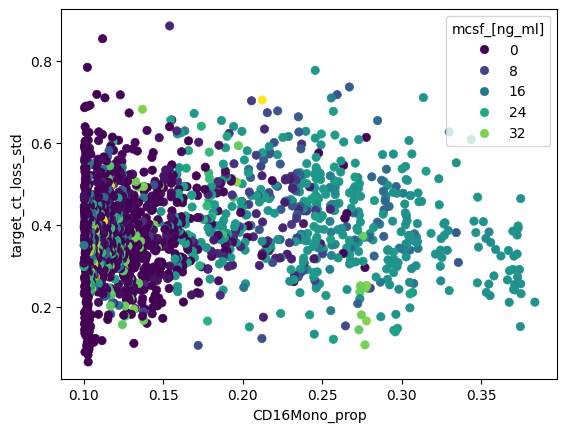

In [13]:
sns.scatterplot(cd16_prop, x="CD16Mono_prop", y="target_ct_loss_std", hue='mcsf_[ng_ml]', palette="viridis", edgecolor=None)

<Axes: xlabel='CD14Mono_prop', ylabel='target_ct_loss_std'>

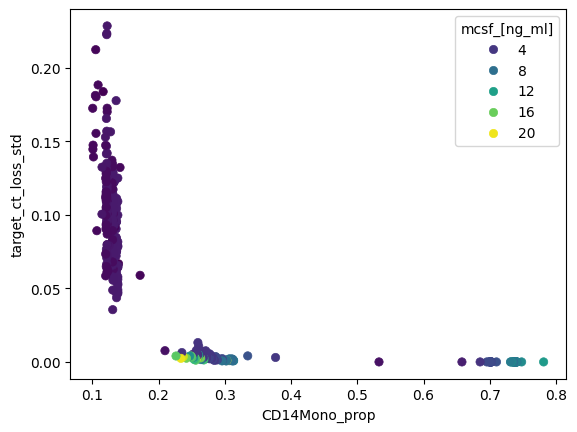

In [14]:
sns.scatterplot(cd14_prop, x="CD14Mono_prop", y="target_ct_loss_std", hue='mcsf_[ng_ml]', palette="viridis", edgecolor=None)

<Axes: xlabel='preProB_prop', ylabel='target_ct_loss_std'>

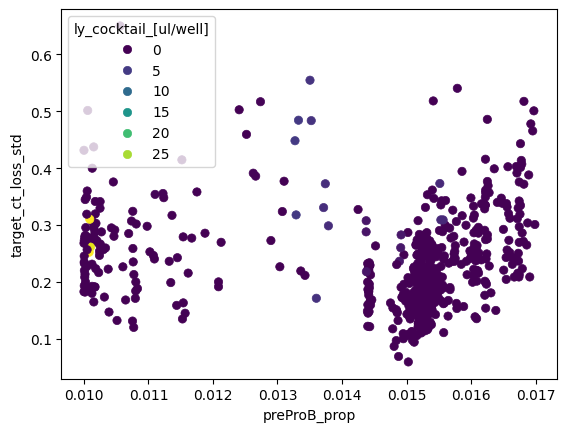

In [15]:
sns.scatterplot(preProB_prop, x="preProB_prop", y="target_ct_loss_std", hue='ly_cocktail_[ul/well]', palette="viridis", edgecolor=None)

# Select and save recipes

### CD16Mono

In [16]:
cd16_prop = cd16_prop.sort_values(by="target_ct_loss_mean")

In [17]:
cd16_prop_filtered = pd.concat([cd16_prop.iloc[:20], cd16_prop.iloc[-20:]])
cd16_prop_filtered = cd16_prop_filtered.sort_values("target_ct_loss_std")

In [18]:
cd16_prop_filtered

,gm-csf_[ng_ml],tpo_[ng_ml],sr1_[nm],um171_[nm],um729_[µm],scf_[ng_ml],butyzamide_[nm],retinoic_acid_[µm],ldl_[ng_ml],il3_[ng_ml],...,run_name,loss,target_ct_loss_std,target_ct_loss_mean,ct_prop_total_variance,il7_[ng_ml],mcsf_[ng_ml],ly_cocktail_[ul/well],CD16Mono_prop,filtering_step
40,6.441736,2.148728,1.982356,0.204493,0.260686,11.997765,0.000000,0.944295,0.136148,0.069764,...,penalized_all_axes-pure_populations-constant,11.968392,0.101892,0.658056,0.001065,0.053201,0.124145,0.012276,0.103276,pass
2,8.102929,0.000000,881.325300,8.777303,0.094951,44.704550,0.042768,28.945057,0.021972,0.000000,...,penalized_all_axes-pure_populations-constant,16.172188,0.106323,0.610049,0.001514,0.000000,9.279296,5.355326,0.171926,pass
2,10.394541,2.137915,636.894400,2042.824600,0.000000,68.325340,0.000000,0.349446,69.346010,0.000000,...,penalized_oxy_days-pure_populations-reciprocal,8.663345,0.107438,0.494204,0.001079,0.090919,31.510020,0.070705,0.276880,pass
40,6.438713,2.303655,0.809378,0.000000,0.407658,40.165413,0.000000,1.241117,0.261713,0.016076,...,penalized_oxy_days-pure_populations-constant,12.021172,0.117994,0.544258,0.001237,0.000000,0.077750,0.035672,0.111390,pass
40,6.252113,2.665077,0.946174,0.555516,0.298832,13.453314,0.000000,0.893880,0.218830,0.049910,...,penalized_oxy_days-pure_populations-constant,11.969955,0.137620,0.671125,0.001498,0.001886,0.147134,0.000000,0.103020,pass
2,9.977325,1.924123,777.864400,1012.968440,0.000000,47.073610,0.916712,0.325795,32.567158,2.920954,...,penalized_all_axes-pure_populations-constant,7.617146,0.139373,0.391933,0.001374,0.009203,21.948666,0.469156,0.296018,pass
2,10.341361,2.153655,637.576200,2049.739300,0.000000,68.373985,0.000000,0.354227,73.952640,0.000000,...,penalized_oxy_days-pure_populations-reciprocal,8.750197,0.144222,0.542058,0.000898,0.088933,30.287195,0.068766,0.273086,pass
2,10.321736,2.144419,834.131040,1127.973600,0.000000,47.980362,1.218965,0.632019,44.798275,0.948380,...,penalized_all_axes-pure_populations-constant,7.983265,0.148008,0.474023,0.002453,0.067360,20.924166,0.354023,0.297331,pass
25,10.345589,2.427315,771.672000,1140.837800,0.000000,51.290176,0.252114,0.430439,17.357872,9.068666,...,penalized_all_axes-pure_populations-constant,6.273813,0.152200,0.676671,0.000777,0.000623,20.555218,0.198769,0.374646,pass
6,9.594031,2.286982,780.678300,963.122800,0.000000,46.412132,0.160957,0.392738,53.375217,2.977610,...,penalized_all_axes-pure_populations-constant,11.286827,0.153775,0.583036,0.000960,0.000263,8.978092,0.614647,0.264635,pass


In [19]:
cd16_prop_filtered.to_csv("../../../../../../project_folder/output/inverse/loss_guidance/manually_filtered/results_loop3_replicate/cd16Mono.csv")

### CD14Mono

In [20]:
cd14_prop = cd14_prop.sort_values(by="target_ct_loss_std")

In [21]:
cd14_prop_filtered = pd.concat([cd14_prop.iloc[:20], cd14_prop.iloc[-20:]])

In [22]:
cd14_prop_filtered

,gm-csf_[ng_ml],tpo_[ng_ml],sr1_[nm],um171_[nm],um729_[µm],scf_[ng_ml],butyzamide_[nm],retinoic_acid_[µm],ldl_[ng_ml],il3_[ng_ml],...,run_name,loss,target_ct_loss_std,target_ct_loss_mean,ct_prop_total_variance,il7_[ng_ml],mcsf_[ng_ml],ly_cocktail_[ul/well],CD14Mono_prop,filtering_step
27,10.371521,0.000000,866.47180,0.162017,0.136870,50.662426,87.423744,0.000000,0.000000,0.007759,...,penalized_all_axes-pure_populations-constant,3.108484,0.000000,0.000000,0.000858,3.042623,11.483781,0.791857,0.781090,pass
11,10.156551,0.000000,789.06210,1.105094,0.481705,51.582520,98.529910,0.000000,0.000000,0.000000,...,penalized_all_axes-pure_populations-constant,4.174963,0.000000,0.000000,0.000626,1.355144,10.265598,0.428554,0.747908,pass
11,10.172447,0.000000,793.94446,1.070245,0.600465,51.507690,97.731766,0.007266,0.015447,0.000000,...,penalized_all_axes-pure_populations-constant,4.256481,0.000000,0.000000,0.000468,1.585065,9.642902,0.481501,0.741024,pass
11,10.372847,0.000000,783.24760,1.016128,0.763333,52.868750,103.367890,0.000000,0.000000,0.000000,...,penalized_all_axes-pure_populations-constant,4.180227,0.000000,0.000000,0.000769,1.396188,9.105454,0.219122,0.740633,pass
11,10.320583,0.023591,773.81340,1.150289,0.506571,52.031685,102.925210,0.005269,0.000000,0.000000,...,penalized_all_axes-pure_populations-constant,4.189375,0.000000,0.000000,0.000887,1.327949,9.380627,0.406926,0.740275,pass
11,10.409283,0.000000,783.63070,1.143060,0.564779,52.877130,103.789566,0.000000,0.000000,0.000000,...,penalized_all_axes-pure_populations-constant,4.214323,0.000000,0.000000,0.000914,1.305322,8.883358,0.439513,0.740032,pass
11,10.428225,0.000000,781.82153,1.235975,0.532652,52.704610,103.943275,0.000000,0.000000,0.000000,...,penalized_all_axes-pure_populations-constant,4.192774,0.000000,0.000000,0.000407,1.400340,9.011854,0.439376,0.739728,pass
11,10.319628,0.025353,773.99445,1.188373,0.527761,52.003838,102.866060,0.000000,0.000000,0.000000,...,penalized_all_axes-pure_populations-constant,4.184160,0.000000,0.000000,0.001499,1.451821,9.356231,0.411626,0.739189,pass
11,10.318312,0.026276,773.06260,1.123032,0.538106,52.047670,103.087930,0.005234,0.000000,0.000000,...,penalized_all_axes-pure_populations-constant,4.227633,0.000000,0.000000,0.001163,1.467759,9.009329,0.436718,0.735828,pass
11,10.252230,0.067042,861.52230,0.281195,0.672365,50.762550,87.338820,0.000000,0.062068,0.008917,...,penalized_all_axes-pure_populations-constant,4.968730,0.000000,0.000000,0.000692,2.256925,7.793411,0.977510,0.735754,pass


In [23]:
cd14_prop_filtered.to_csv("../../../../../../project_folder/output/inverse/loss_guidance/manually_filtered/results_loop3_replicate/cd14Mono.csv")

### preProB

In [24]:
preProB_prop = preProB_prop.sort_values(by="target_ct_loss_std")

In [25]:
preProB_prop_filtered = pd.concat([preProB_prop.iloc[:20], preProB_prop.iloc[-20:]])

In [26]:
preProB_prop_filtered["ly_cocktail_[ul/well]"].max()

np.float64(4.8840184)

In [27]:
preProB_prop_filtered.to_csv("../../../../../../project_folder/output/inverse/loss_guidance/manually_filtered/results_loop3_replicate/preProB.csv")

In [28]:
preProB_prop.to_csv("../../../../../../project_folder/output/inverse/loss_guidance/manually_filtered/results_loop3_replicate/preProB_UNFILTERED.csv")